<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [245]:
from google.colab import files

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [247]:
uploaded = files.upload()

Saving car details.csv to car details.csv


In [248]:

df = pd.read_csv('car details.csv')

df['Engine_CC'] = df['Engine'].str.replace(' cc', '', regex=False).astype(float)

df['Max_Power_BHP'] = df['Max Power'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Max_Torque_NM'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)').astype(float)

numerical_features = [
    'Price', 'Year', 'Kilometer', 'Engine_CC', 'Max_Power_BHP',
    'Max_Torque_NM', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity'
]
X = df[numerical_features].copy()

In [249]:
for col in X.columns:
    X[col].fillna(X[col].median(), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_features)

/tmp/ipython-input-2125735321.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


In [250]:
sample_size = 100
np.random.seed(42)
sample_indices = np.random.choice(X_scaled_df.index, size=sample_size, replace=False)
X_sample = X_scaled_df.iloc[sample_indices].values
sample_labels = df.iloc[sample_indices]['Model'].tolist()

linkage_methods = ['single', 'complete', 'average']

In [251]:
for method in linkage_methods:
    # Compute the linkage matrix
    Z = linkage(X_sample, method=method, metric='euclidean')

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [5.0, 5.0, 22.5, 22.5],
  [55.0, 55.0, 65.0, 65.0],
  [75.0, 75.0, 85.0, 85.0],
  [60.0, 60.0, 80.0, 80.0],
  [45.0, 45.0, 70.0, 70.0],
  [13.75, 13.75, 57.5, 57.5],
  [105.0, 105.0, 115.0, 115.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [110.0, 110.0, 132.5, 132.5],
  [95.0, 95.0, 121.25, 121.25],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [108.125, 108.125, 162.5, 162.5],
  [35.625, 35.625, 135.3125, 135.3125],
  [185.0, 185.0, 195.0, 195.0],
  [85.46875, 85.46875, 190.0, 190.0]],
 'dcoord': [[0.0,
   np.float64(2.550162096270559),
   np.float64(2.550162096270559),
   0.0],
  [0.0,
   np.float64(2.845007102229447),
   np.float64(2.845007102229447),
   np.float64(2.550162096270559)],
  [0.0,
   np.float64(3.579322205136942),
   np.float64(3.579322205136942),
   np.float64(2.845007102229447)],
  [0.0, np.float64(2.662936623717152), np.float64(2.662936623717152), 0.0],
  

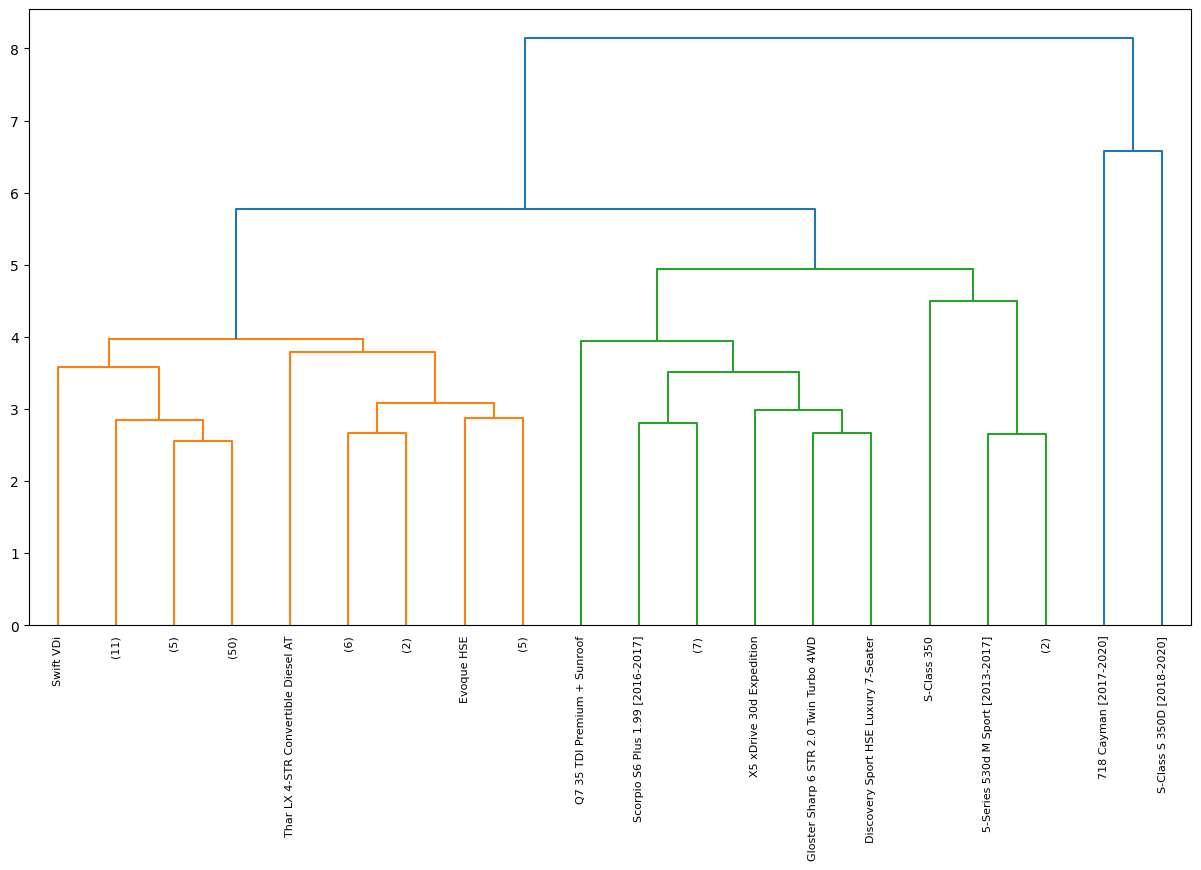

In [252]:
plt.figure(figsize=(15, 8))
dendrogram(Z,
            labels=sample_labels,
            leaf_rotation=90.,
            leaf_font_size=8.,
            truncate_mode='lastp', # Truncate to the last 'p' merged clusters
            p=20, # Show only the last 20 merged clusters
            show_leaf_counts=True)

In [253]:
plt.title(f'Agglomerative Hierarchical Clustering Dendrogram (Linkage: {method.capitalize()})')
plt.xlabel('Sample Index or Cluster Size (for truncated)')
plt.ylabel('Distance (Euclidean)')
plt.tight_layout()
plt.savefig(f'dendrogram_{method}.png')
plt.close()

In [254]:
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [255]:
n_clusters = 5
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
cluster_labels = agg_clustering.fit_predict(X_scaled_df)

In [256]:
df['Agglomerative_Cluster_5_Complete'] = cluster_labels
print("\nFirst 5 Agglomerative Cluster Labels (Complete Linkage, K=5):")
print(df[['Make', 'Model', 'Agglomerative_Cluster_5_Complete']].head())


First 5 Agglomerative Cluster Labels (Complete Linkage, K=5):
            Make                            Model  \
0          Honda              Amaze 1.2 VX i-VTEC   
1  Maruti Suzuki                  Swift DZire VDI   
2        Hyundai             i10 Magna 1.2 Kappa2   
3         Toyota                         Glanza G   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]   

   Agglomerative_Cluster_5_Complete  
0                                 0  
1                                 0  
2                                 0  
3                                 0  
4                                 0  
